In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/usdot/flight-delays/airports.csv
/kaggle/input/datasets/usdot/flight-delays/airlines.csv
/kaggle/input/datasets/usdot/flight-delays/flights.csv


In [3]:
# Check the structure of the flight dataset

flights_path = "/kaggle/input/datasets/usdot/flight-delays/flights.csv"

# Read only the first 5 rows
flights_sample = pd.read_csv(flights_path, nrows=5)

print("Columns in the dataset:")
print(flights_sample.columns.tolist())

print("\nFirst 5 rows:")
display(flights_sample)

Columns in the dataset:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

First 5 rows:


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408,-22,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741,-9,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811,5,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756,-9,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259,-21,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Load the flight dataset

flights_path = "/kaggle/input/datasets/usdot/flight-delays/flights.csv"

flights = pd.read_csv(flights_path)

print("Dataset loaded successfully!")
print("Rows:", flights.shape[0])
print("Columns:", flights.shape[1])

/tmp/ipykernel_58/328184528.py:5: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv(flights_path)


Dataset loaded successfully!
Rows: 5819079
Columns: 31


In [5]:
# Check missing values in each column

missing_values = flights.isnull().sum()

missing_percentage = (missing_values / len(flights)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage.round(2)
})

missing_summary = missing_summary.sort_values(
    by='Missing Values',
    ascending=False
)

display(missing_summary)

,Missing Values,Missing Percentage
CANCELLATION_REASON,5729195,98.46
LATE_AIRCRAFT_DELAY,4755640,81.72
WEATHER_DELAY,4755640,81.72
AIRLINE_DELAY,4755640,81.72
AIR_SYSTEM_DELAY,4755640,81.72
SECURITY_DELAY,4755640,81.72
ELAPSED_TIME,105071,1.81
AIR_TIME,105071,1.81
ARRIVAL_DELAY,105071,1.81
WHEELS_ON,92513,1.59


In [6]:
# Create a copy of the original dataset
df = flights.copy()

print("Original rows:", len(df))
print("Original columns:", len(df.columns))

Original rows: 5819079
Original columns: 31


In [8]:
# Convert important columns to numeric values
numeric_columns = [
    'DEPARTURE_DELAY',
    'ARRIVAL_DELAY',
    'DISTANCE',
    'AIR_TIME',
    'ELAPSED_TIME'
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

print("Data types cleaned successfully!")

Data types cleaned successfully!


In [9]:
# Create useful columns for analysis

# Flight status
df['FLIGHT_STATUS'] = np.where(
    df['CANCELLED'] == 1,
    'Cancelled',
    np.where(
        df['ARRIVAL_DELAY'] > 0,
        'Delayed',
        'On Time'
    )
)

# Delay category
df['DELAY_CATEGORY'] = pd.cut(
    df['ARRIVAL_DELAY'],
    bins=[-np.inf, 0, 15, 60, np.inf],
    labels=['On Time/Early', 'Minor Delay', 'Moderate Delay', 'Severe Delay']
)

# Month names
month_names = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

df['MONTH_NAME'] = df['MONTH'].map(month_names)

print("New analysis columns created!")

New analysis columns created!


In [10]:
# Count different flight statuses

status_counts = df['FLIGHT_STATUS'].value_counts()

print("Flight Status Summary")
print("---------------------")

for status, count in status_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{status}: {count:,} ({percentage:.2f}%)")

Flight Status Summary
---------------------
On Time: 3,642,299 (62.59%)
Delayed: 2,086,896 (35.86%)
Cancelled: 89,884 (1.54%)


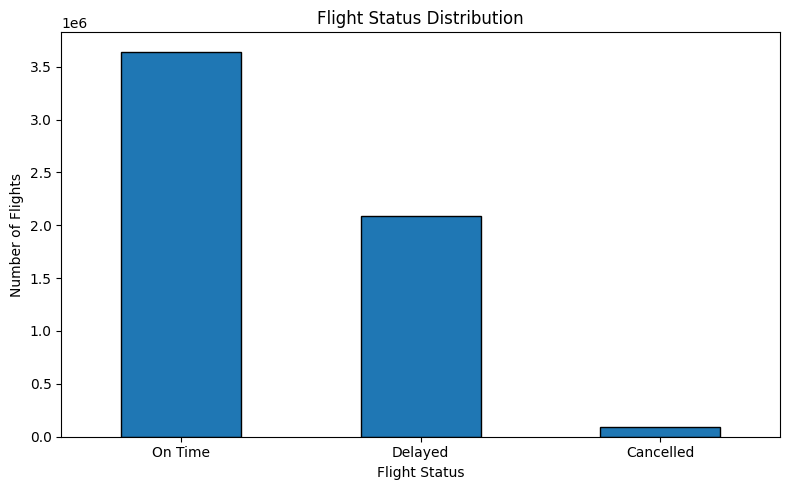

In [11]:
# Visualize flight status

plt.figure(figsize=(8, 5))

status_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Flight Status Distribution')
plt.xlabel('Flight Status')
plt.ylabel('Number of Flights')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Correct the flight status classification

df['FLIGHT_STATUS'] = np.select(
    [
        df['CANCELLED'] == 1,
        df['ARRIVAL_DELAY'].isna(),
        df['ARRIVAL_DELAY'] > 0
    ],
    [
        'Cancelled',
        'Unknown',
        'Delayed'
    ],
    default='On Time'
)

# Check the corrected results
status_counts = df['FLIGHT_STATUS'].value_counts()

print("Corrected Flight Status Summary")
print("--------------------------------")

for status, count in status_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{status}: {count:,} ({percentage:.2f}%)")

Corrected Flight Status Summary
--------------------------------
On Time: 3,627,112 (62.33%)
Delayed: 2,086,896 (35.86%)
Cancelled: 89,884 (1.54%)
Unknown: 15,187 (0.26%)


In [13]:
# Calculate average departure and arrival delays

avg_departure_delay = df['DEPARTURE_DELAY'].mean()
avg_arrival_delay = df['ARRIVAL_DELAY'].mean()

print("Average Delay Analysis")
print("----------------------")
print(f"Average Departure Delay: {avg_departure_delay:.2f} minutes")
print(f"Average Arrival Delay: {avg_arrival_delay:.2f} minutes")

Average Delay Analysis
----------------------
Average Departure Delay: 9.37 minutes
Average Arrival Delay: 4.41 minutes


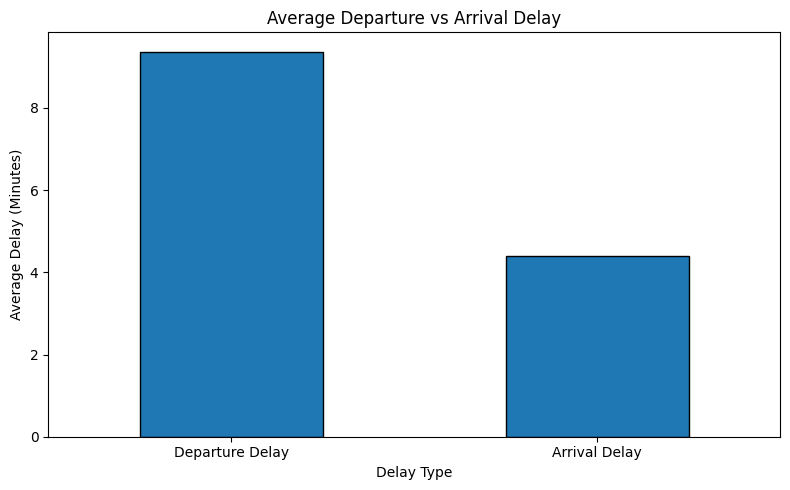

In [14]:
# Average departure vs arrival delay

delay_comparison = pd.Series({
    'Departure Delay': df['DEPARTURE_DELAY'].mean(),
    'Arrival Delay': df['ARRIVAL_DELAY'].mean()
})

plt.figure(figsize=(8, 5))

delay_comparison.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Departure vs Arrival Delay')
plt.xlabel('Delay Type')
plt.ylabel('Average Delay (Minutes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# Average arrival delay by airline

airline_delay = (
    df[df['ARRIVAL_DELAY'].notna()]
    .groupby('AIRLINE')['ARRIVAL_DELAY']
    .mean()
    .sort_values(ascending=False)
)

print("Average Arrival Delay by Airline")
print("--------------------------------")

for airline, delay in airline_delay.items():
    print(f"{airline}: {delay:.2f} minutes")

Average Arrival Delay by Airline
--------------------------------
NK: 14.47 minutes
F9: 12.50 minutes
B6: 6.68 minutes
EV: 6.59 minutes
MQ: 6.46 minutes
OO: 5.85 minutes
UA: 5.43 minutes
VX: 4.74 minutes
WN: 4.37 minutes
US: 3.71 minutes
AA: 3.45 minutes
HA: 2.02 minutes
DL: 0.19 minutes
AS: -0.98 minutes


In [16]:
airline_delay_rate = (
    df[df['ARRIVAL_DELAY'].notna()]
    .groupby('AIRLINE')
    .agg(
        Total_Flights=('ARRIVAL_DELAY', 'count'),
        Delayed_Flights=('ARRIVAL_DELAY', lambda x: (x > 0).sum())
    )
)

airline_delay_rate['Delay_Rate_%'] = (
    airline_delay_rate['Delayed_Flights']
    / airline_delay_rate['Total_Flights']
    * 100
)

airline_delay_rate = airline_delay_rate.sort_values(
    'Delay_Rate_%',
    ascending=False
)

print("Delay Rate by Airline")
print("---------------------")
display(airline_delay_rate)

Delay Rate by Airline
---------------------


,Total_Flights,Delayed_Flights,Delay_Rate_%
AIRLINE,,,
NK,115193,56887,49.384077
F9,90090,41232,45.767566
HA,76041,30179,39.687800
VX,61248,24180,39.478840
US,194223,76285,39.277017
B6,262042,101998,38.924295
OO,576814,222435,38.562691
EV,554752,213217,38.434652
WN,1242403,470767,37.891650


In [17]:
# Load airline information

airlines_path = "/kaggle/input/datasets/usdot/flight-delays/airlines.csv"

airlines = pd.read_csv(airlines_path)

print("Airline information:")
display(airlines)

Airline information:


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways
5,OO,Skywest Airlines Inc.
6,AS,Alaska Airlines Inc.
7,NK,Spirit Air Lines
8,WN,Southwest Airlines Co.
9,DL,Delta Air Lines Inc.


In [22]:
print(airline_analysis.columns.tolist())

['AIRLINE_x', 'Total_Flights', 'Delayed_Flights', 'Delay_Rate_%', 'IATA_CODE', 'AIRLINE_y']


In [23]:
# Clean up the airline analysis table

airline_analysis = airline_analysis.rename(columns={
    'AIRLINE_x': 'AIRLINE',
    'AIRLINE_y': 'AIRLINE_NAME'
})

# Keep only the columns we need
airline_analysis = airline_analysis[
    ['AIRLINE', 'AIRLINE_NAME', 'Total_Flights',
     'Delayed_Flights', 'Delay_Rate_%']
]

# Display the final table
display(airline_analysis)

,AIRLINE,AIRLINE_NAME,Total_Flights,Delayed_Flights,Delay_Rate_%
0,NK,Spirit Air Lines,115193,56887,49.384077
1,F9,Frontier Airlines Inc.,90090,41232,45.767566
2,HA,Hawaiian Airlines Inc.,76041,30179,39.687800
3,VX,Virgin America,61248,24180,39.478840
4,US,US Airways Inc.,194223,76285,39.277017
5,B6,JetBlue Airways,262042,101998,38.924295
6,OO,Skywest Airlines Inc.,576814,222435,38.562691
7,EV,Atlantic Southeast Airlines,554752,213217,38.434652
8,WN,Southwest Airlines Co.,1242403,470767,37.891650
9,MQ,American Eagle Airlines Inc.,278791,103505,37.126378


In [24]:
delay_causes = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]

cause_totals = df[delay_causes].sum().sort_values(ascending=False)

print("Total Delay Minutes by Cause")
print("----------------------------")
print(cause_totals)

Total Delay Minutes by Cause
----------------------------
LATE_AIRCRAFT_DELAY    24961931.0
AIRLINE_DELAY          20172956.0
AIR_SYSTEM_DELAY       14335762.0
WEATHER_DELAY           3100233.0
SECURITY_DELAY            80985.0
dtype: float64


In [25]:
# Number of flights affected by each delay cause

cause_flight_counts = {}

for cause in delay_causes:
    cause_flight_counts[cause] = (df[cause] > 0).sum()

cause_flight_counts = pd.Series(cause_flight_counts).sort_values(
    ascending=False
)

print("Number of Flights Affected by Each Delay Cause")
print("-----------------------------------------------")

for cause, count in cause_flight_counts.items():
    print(f"{cause}: {count:,} flights")

Number of Flights Affected by Each Delay Cause
-----------------------------------------------
AIRLINE_DELAY: 570,022 flights
AIR_SYSTEM_DELAY: 564,826 flights
LATE_AIRCRAFT_DELAY: 556,953 flights
WEATHER_DELAY: 64,716 flights
SECURITY_DELAY: 3,484 flights


In [26]:
monthly_delay = (
    df.groupby('MONTH')
    .agg(
        Total_Flights=('FLIGHT_STATUS', 'count'),
        Delayed_Flights=('FLIGHT_STATUS', lambda x: (x == 'Delayed').sum()),
        Cancelled_Flights=('FLIGHT_STATUS', lambda x: (x == 'Cancelled').sum())
    )
)

monthly_delay['Delay_Rate_%'] = (
    monthly_delay['Delayed_Flights']
    / monthly_delay['Total_Flights']
    * 100
)

monthly_delay['Cancellation_Rate_%'] = (
    monthly_delay['Cancelled_Flights']
    / monthly_delay['Total_Flights']
    * 100
)

monthly_delay

,Total_Flights,Delayed_Flights,Cancelled_Flights,Delay_Rate_%,Cancellation_Rate_%
MONTH,,,,,
1,469968,183110,11982,38.962227,2.549535
2,429191,175443,20517,40.877605,4.780389
3,504312,190133,11002,37.701463,2.181586
4,485151,171820,4520,35.415778,0.931669
5,496993,175178,5694,35.247579,1.145690
6,503897,206989,9120,41.077641,1.809894
7,520718,199717,4806,38.354157,0.922956
8,510536,180891,5052,35.431586,0.989548
9,464946,133432,2075,28.698386,0.446288


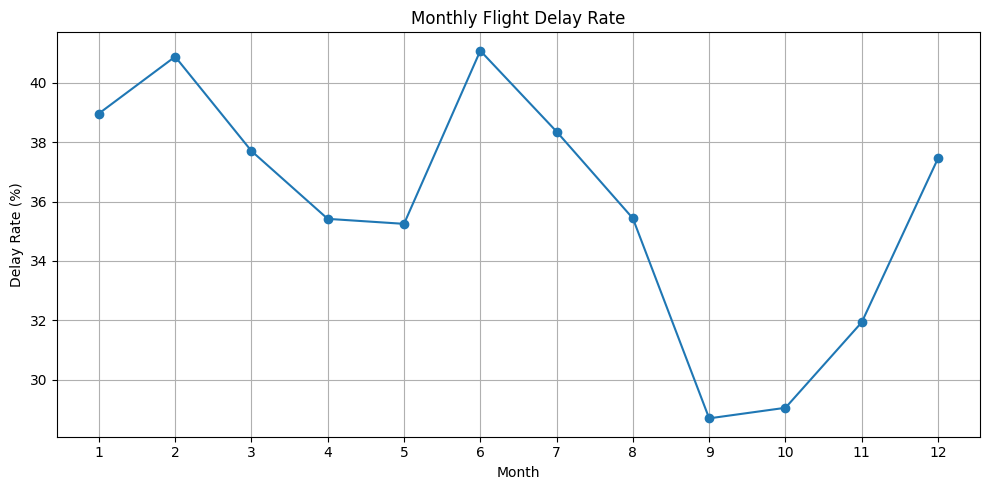

In [27]:
# Monthly delay rate

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_delay.index,
    monthly_delay['Delay_Rate_%'],
    marker='o'
)

plt.title('Monthly Flight Delay Rate')
plt.xlabel('Month')
plt.ylabel('Delay Rate (%)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

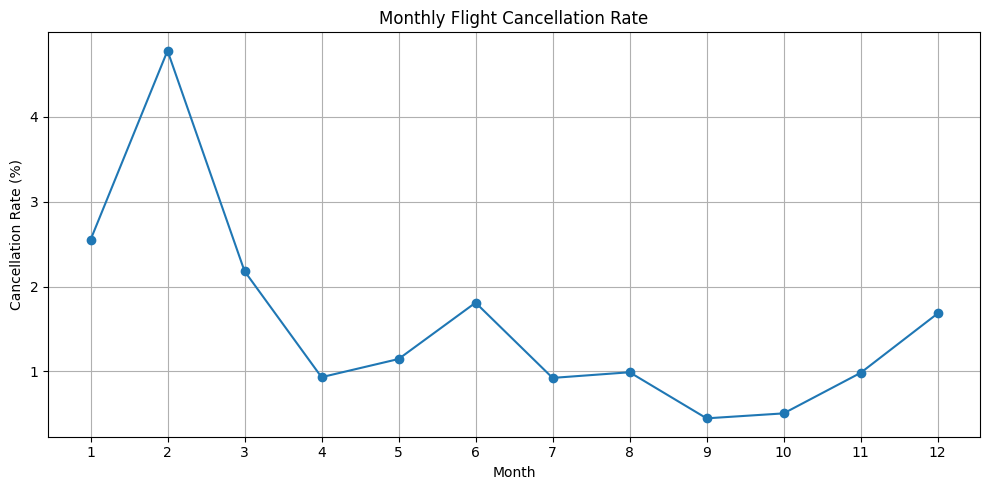

In [28]:
# Monthly cancellation rate

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_delay.index,
    monthly_delay['Cancellation_Rate_%'],
    marker='o'
)

plt.title('Monthly Flight Cancellation Rate')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
airport_flights = (
    df.groupby('ORIGIN_AIRPORT')
    .size()
    .reset_index(name='Total_Flights')
    .sort_values('Total_Flights', ascending=False)
)

print("Top 15 Busiest Origin Airports")
print(airport_flights.head(15))

Top 15 Busiest Origin Airports
    ORIGIN_AIRPORT  Total_Flights
628            ATL         346836
836            ORD         285884
694            DFW         239551
693            DEN         196055
784            LAX         194673
886            SFO         148008
847            PHX         146815
759            IAH         146622
782            LAS         133181
824            MSP         112117
801            MCO         110982
885            SEA         110899
701            DTW         108500
647            BOS         107847
714            EWR         101772


In [30]:
# Calculate delay rate by origin airport

airport_delay = (
    df[df['ARRIVAL_DELAY'].notna()]
    .groupby('ORIGIN_AIRPORT')
    .agg(
        Total_Flights=('ARRIVAL_DELAY', 'count'),
        Delayed_Flights=('ARRIVAL_DELAY', lambda x: (x > 0).sum())
    )
)

airport_delay['Delay_Rate_%'] = (
    airport_delay['Delayed_Flights']
    / airport_delay['Total_Flights']
    * 100
)

# Only consider airports with at least 10,000 flights
airport_delay = airport_delay[
    airport_delay['Total_Flights'] >= 10000
].sort_values('Delay_Rate_%', ascending=False)

print("Top 15 Airports by Delay Rate")
print("-----------------------------")
display(airport_delay.head(15))

Top 15 Airports by Delay Rate
-----------------------------


,Total_Flights,Delayed_Flights,Delay_Rate_%
ORIGIN_AIRPORT,,,
DAL,58672,26612,45.357240
OAK,41669,18409,44.179126
HOU,51132,21963,42.953532
CLT,99052,41441,41.837621
DEN,193402,80756,41.755514
IAH,144019,59824,41.538964
LAX,192003,79661,41.489456
BWI,84329,34979,41.479206
ORD,276554,113281,40.961621


In [31]:
# Calculate route-level flight volume and delay rate

route_analysis = (
    df[df['ARRIVAL_DELAY'].notna()]
    .groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])
    .agg(
        Total_Flights=('ARRIVAL_DELAY', 'count'),
        Delayed_Flights=('ARRIVAL_DELAY', lambda x: (x > 0).sum())
    )
)

route_analysis['Delay_Rate_%'] = (
    route_analysis['Delayed_Flights']
    / route_analysis['Total_Flights']
    * 100
)

# Keep routes with at least 5,000 flights
route_analysis = route_analysis[
    route_analysis['Total_Flights'] >= 5000
].sort_values('Total_Flights', ascending=False)

print("Top 15 Busiest Flight Routes")
print("---------------------------")
display(route_analysis.head(15).reset_index())

Top 15 Busiest Flight Routes
---------------------------


,ORIGIN_AIRPORT,DESTINATION_AIRPORT,Total_Flights,Delayed_Flights,Delay_Rate_%
0,SFO,LAX,13400,6431,47.992537
1,LAX,SFO,13109,5845,44.587688
2,JFK,LAX,11853,3857,32.540285
3,LAX,JFK,11851,3972,33.516159
4,LAS,LAX,9651,4974,51.538701
5,LAX,LAS,9522,4195,44.055871
6,LGA,ORD,9179,3154,34.361042
7,ORD,LGA,9101,3640,39.995605
8,SFO,JFK,8306,2701,32.518661
9,JFK,SFO,8301,2798,33.706782


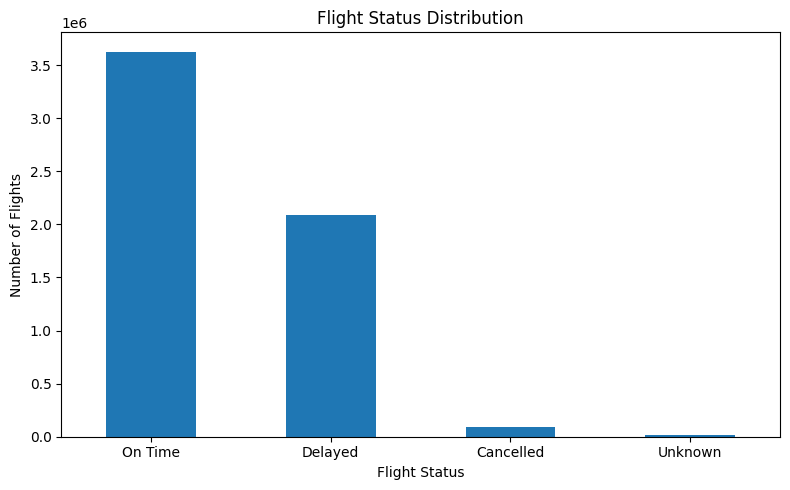

In [32]:
import matplotlib.pyplot as plt

status_counts = df['FLIGHT_STATUS'].value_counts()

plt.figure(figsize=(8,5))
status_counts.plot(kind='bar')

plt.title('Flight Status Distribution')
plt.xlabel('Flight Status')
plt.ylabel('Number of Flights')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

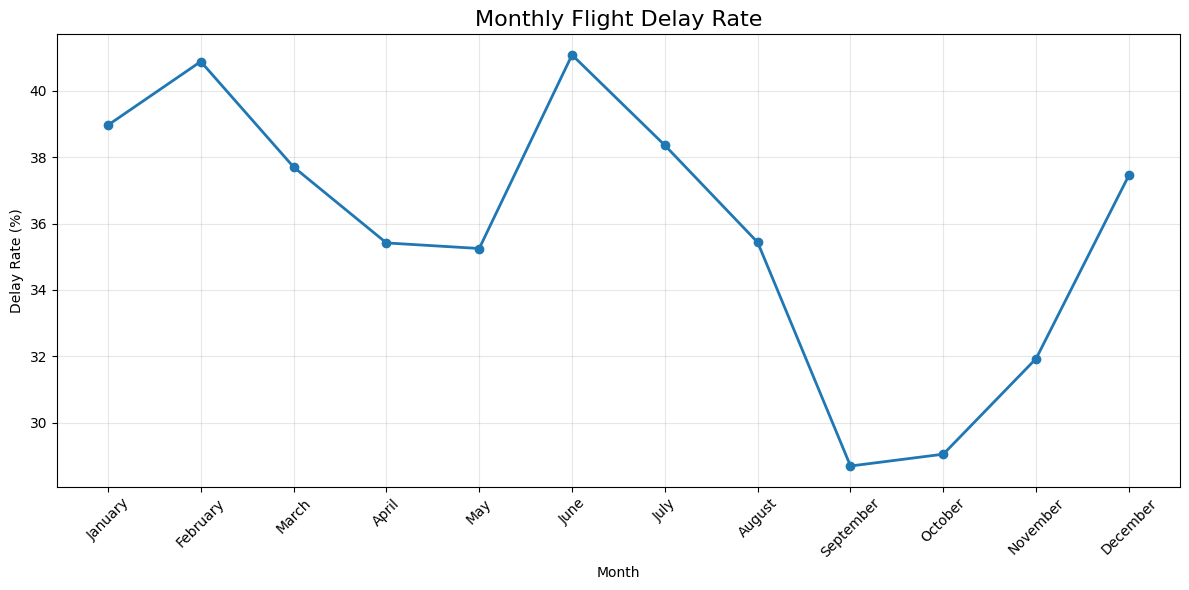

In [33]:
import matplotlib.pyplot as plt

# Month names
months = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

plt.figure(figsize=(12, 6))

plt.plot(
    months,
    monthly_delay['Delay_Rate_%'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Flight Delay Rate', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Delay Rate (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

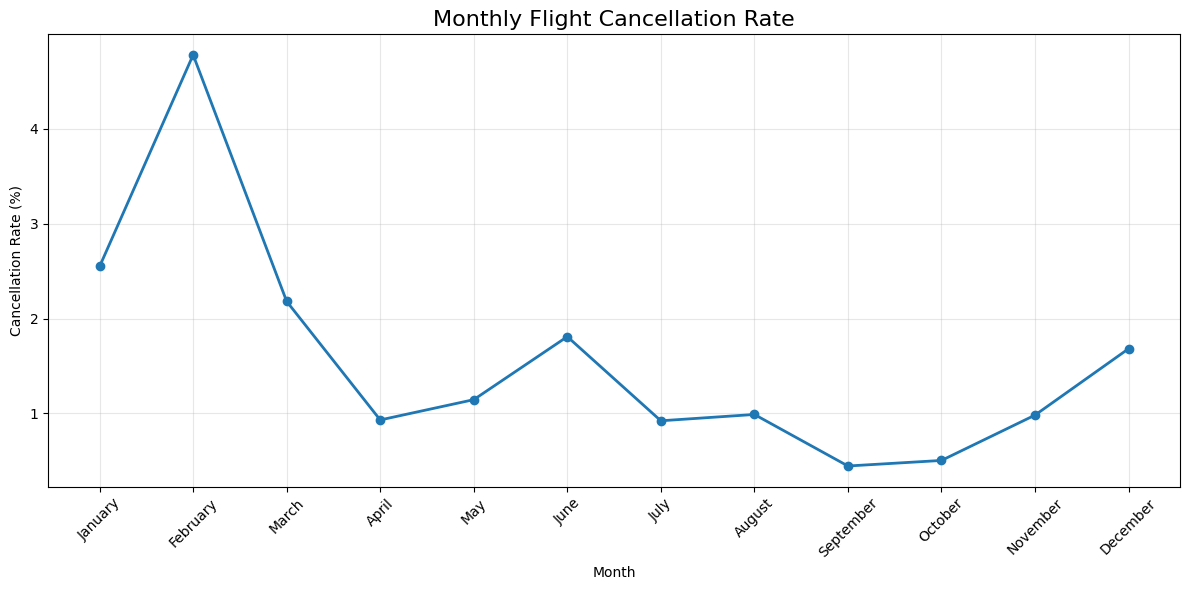

In [34]:
plt.figure(figsize=(12, 6))

plt.plot(
    months,
    monthly_delay['Cancellation_Rate_%'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Flight Cancellation Rate', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

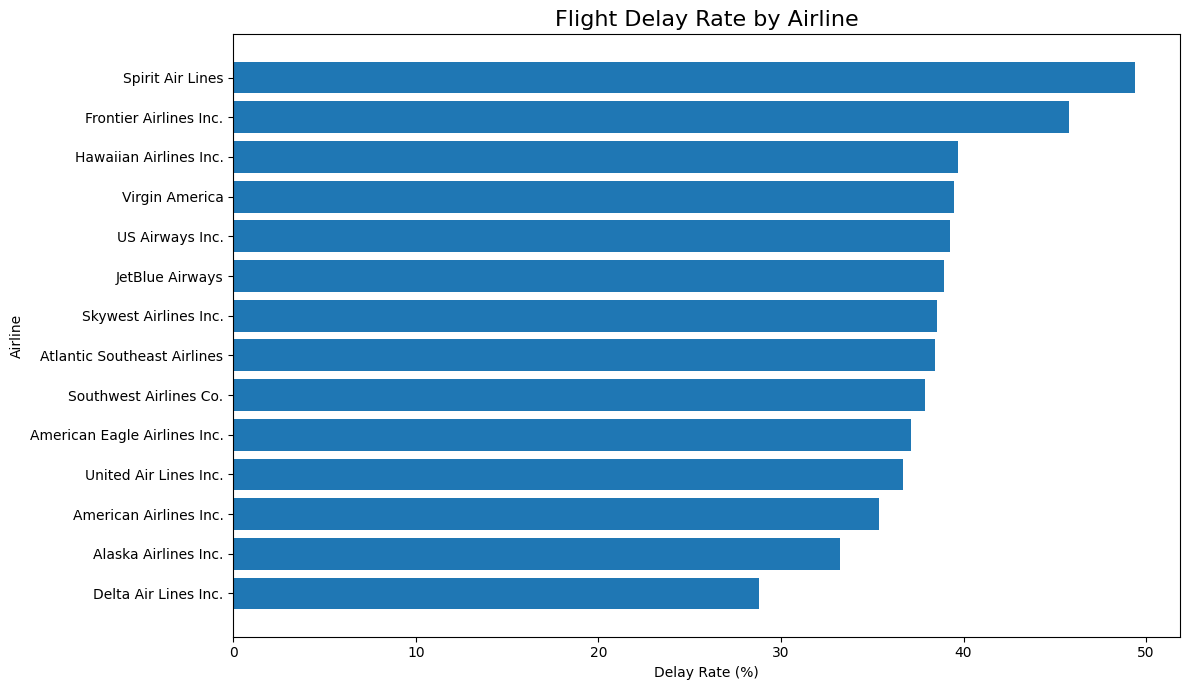

In [35]:
plt.figure(figsize=(12, 7))

airline_chart = airline_analysis.sort_values(
    'Delay_Rate_%',
    ascending=True
)

plt.barh(
    airline_chart['AIRLINE_NAME'],
    airline_chart['Delay_Rate_%']
)

plt.title('Flight Delay Rate by Airline', fontsize=16)
plt.xlabel('Delay Rate (%)')
plt.ylabel('Airline')
plt.tight_layout()
plt.show()

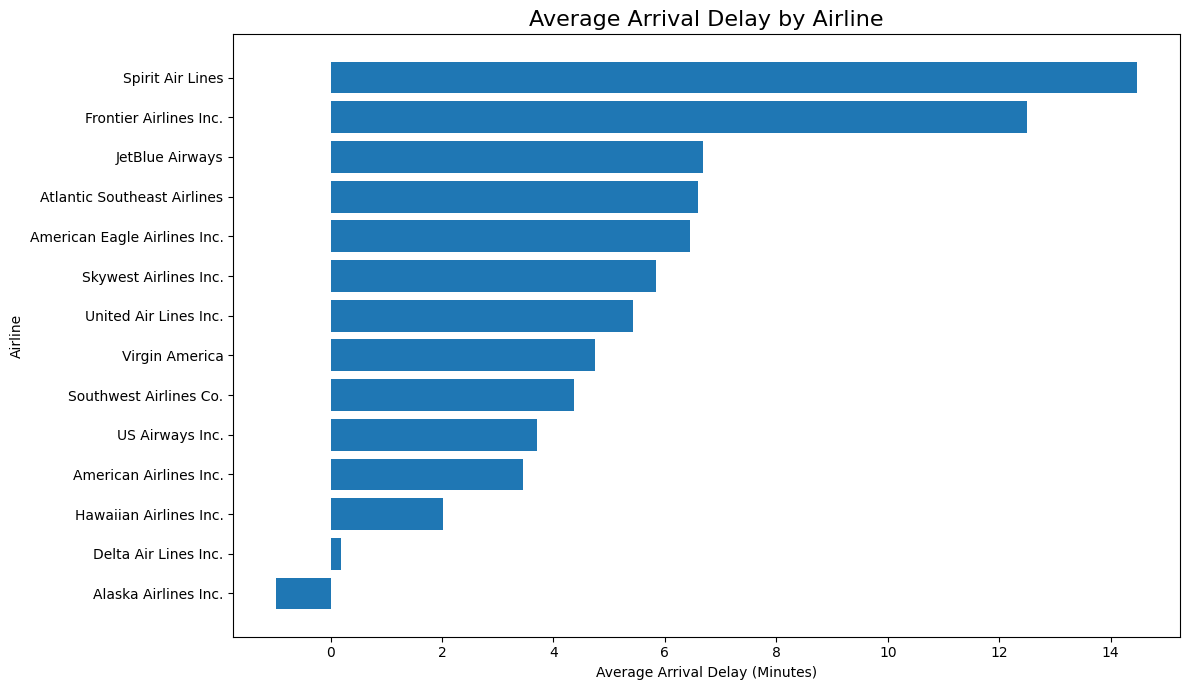

In [36]:
plt.figure(figsize=(12, 7))

avg_airline_delay = (
    df[df['ARRIVAL_DELAY'].notna()]
    .groupby('AIRLINE')['ARRIVAL_DELAY']
    .mean()
    .sort_values()
)

# Add airline names
avg_airline_delay_df = avg_airline_delay.reset_index().merge(
    airlines,
    left_on='AIRLINE',
    right_on='IATA_CODE',
    how='left'
)

plt.barh(
    avg_airline_delay_df['AIRLINE_y'],
    avg_airline_delay_df['ARRIVAL_DELAY']
)

plt.title('Average Arrival Delay by Airline', fontsize=16)
plt.xlabel('Average Arrival Delay (Minutes)')
plt.ylabel('Airline')
plt.tight_layout()
plt.show()

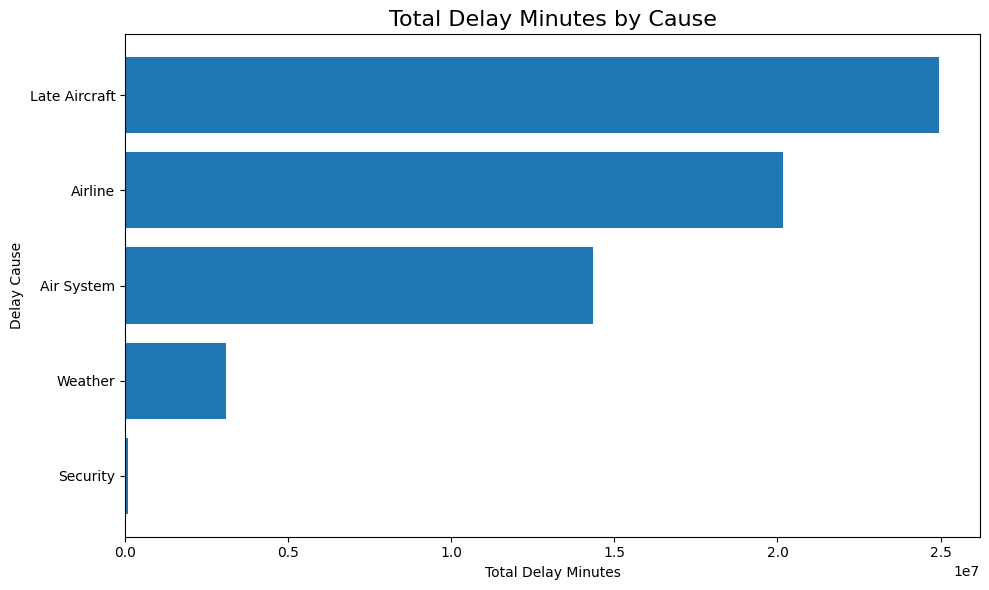

In [37]:
plt.figure(figsize=(10, 6))

cause_chart = cause_totals.sort_values()

cause_names = {
    'AIR_SYSTEM_DELAY': 'Air System',
    'SECURITY_DELAY': 'Security',
    'AIRLINE_DELAY': 'Airline',
    'LATE_AIRCRAFT_DELAY': 'Late Aircraft',
    'WEATHER_DELAY': 'Weather'
}

cause_chart.index = cause_chart.index.map(cause_names)

plt.barh(
    cause_chart.index,
    cause_chart.values
)

plt.title('Total Delay Minutes by Cause', fontsize=16)
plt.xlabel('Total Delay Minutes')
plt.ylabel('Delay Cause')
plt.tight_layout()
plt.show()

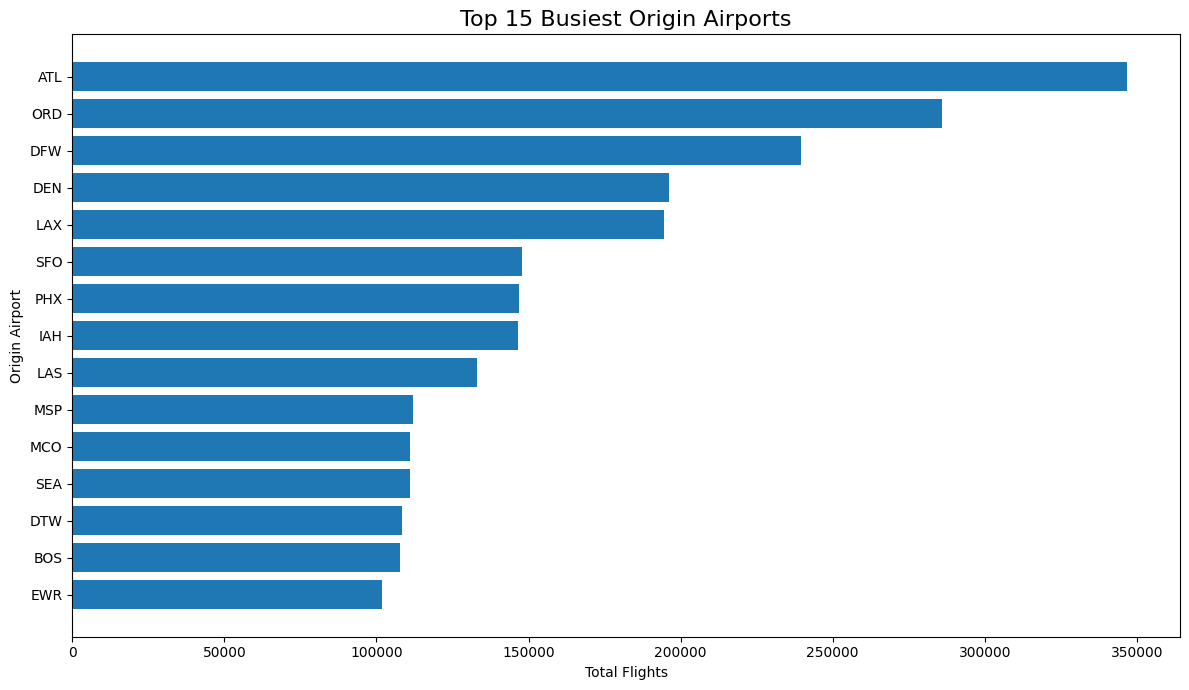

In [38]:
plt.figure(figsize=(12, 7))

top_airports = airport_flights.head(15).sort_values(
    'Total_Flights'
)

plt.barh(
    top_airports['ORIGIN_AIRPORT'],
    top_airports['Total_Flights']
)

plt.title('Top 15 Busiest Origin Airports', fontsize=16)
plt.xlabel('Total Flights')
plt.ylabel('Origin Airport')
plt.tight_layout()
plt.show()

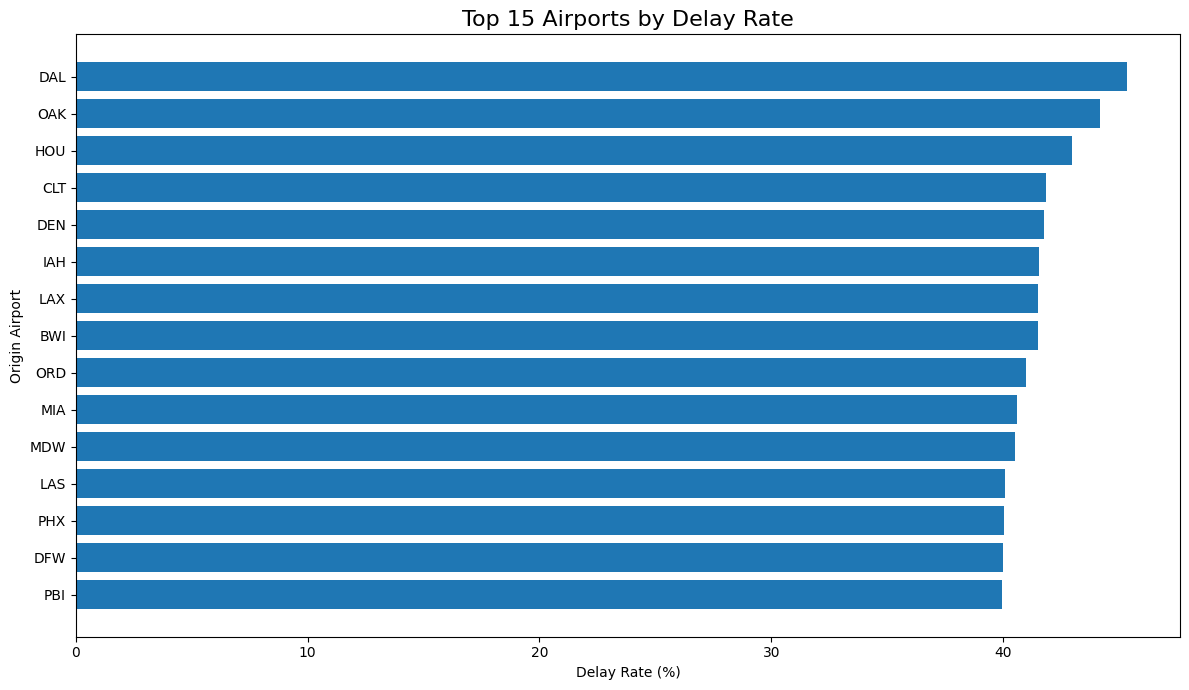

In [39]:
plt.figure(figsize=(12, 7))

top_delay_airports = airport_delay.head(15).sort_values(
    'Delay_Rate_%'
)

plt.barh(
    top_delay_airports.index,
    top_delay_airports['Delay_Rate_%']
)

plt.title('Top 15 Airports by Delay Rate', fontsize=16)
plt.xlabel('Delay Rate (%)')
plt.ylabel('Origin Airport')
plt.tight_layout()
plt.show()

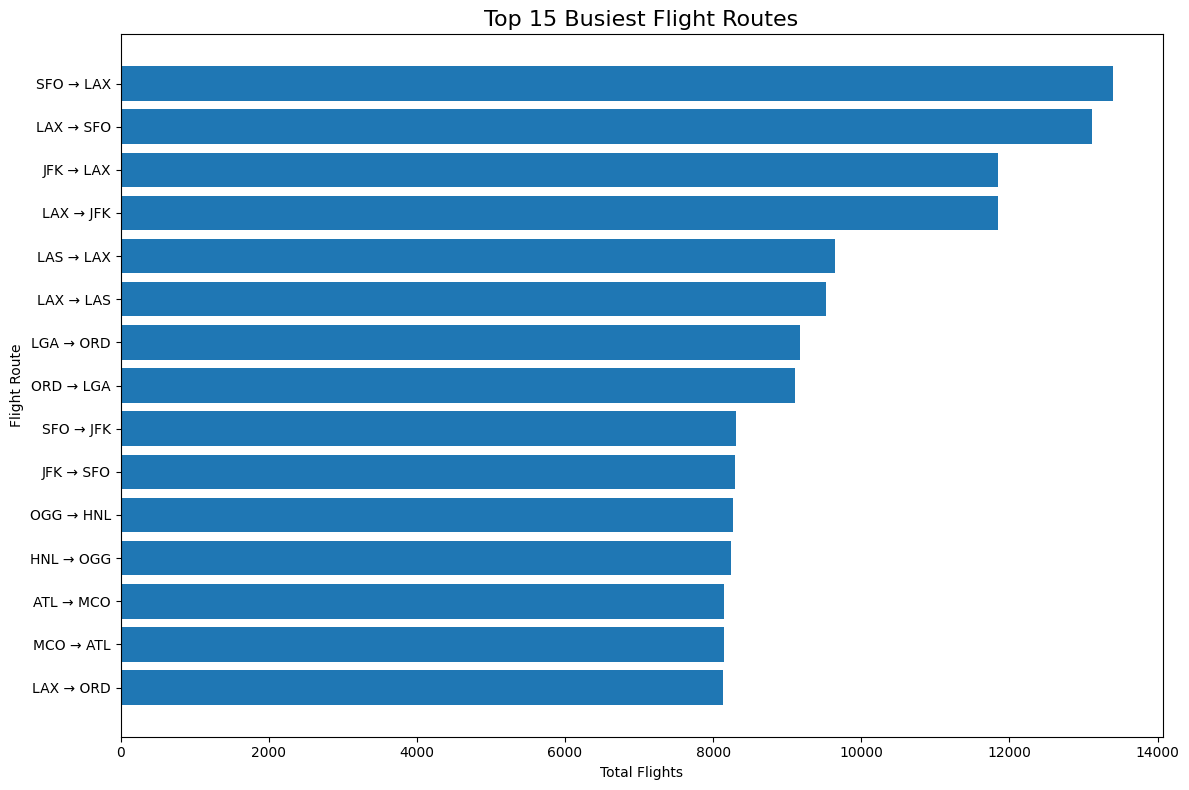

In [40]:
plt.figure(figsize=(12, 8))

top_routes = (
    route_analysis
    .head(15)
    .reset_index()
    .sort_values('Total_Flights')
)

top_routes['ROUTE'] = (
    top_routes['ORIGIN_AIRPORT']
    + ' → ' +
    top_routes['DESTINATION_AIRPORT']
)

plt.barh(
    top_routes['ROUTE'],
    top_routes['Total_Flights']
)

plt.title('Top 15 Busiest Flight Routes', fontsize=16)
plt.xlabel('Total Flights')
plt.ylabel('Flight Route')
plt.tight_layout()
plt.show()